# Aplicação Estratégica — as cinco perguntas, respondidas pelo classificador

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Os notebooks anteriores construíram o dado ([01](01_pipeline_medalhao.ipynb)), entenderam o
problema ([02](02_analise_exploratoria.ipynb)) e ajustaram o modelo
([03](03_modelagem.ipynb)). Este responde às cinco perguntas de negócio do enunciado, para uma
audiência de gestor público.

**Um único modelo responde a todas as cinco.** O enunciado pede um modelo **supervisionado**;
nada aqui usa um segundo modelo por trás.

| # | Pergunta do enunciado | Seção | O que do modelo responde |
|---|---|---|---|
| 1 | Quais fatores mais impactam a alfabetização? | §1 | coeficientes, traduzidos em pontos percentuais de risco |
| 5 | Quais variáveis possuem maior influência no modelo? | §1 | permutation importance e SHAP |
| 2 | Quais municípios apresentam maior risco educacional? | §2 | a **saída direta** do classificador: `P(em risco)` |
| 3 | Quais regiões possuem padrões semelhantes? | §3 | risco previsto por região **+ os fatores que o empurram** |
| 4 | Como prever municípios que podem não atingir metas futuras? | §4 | risco previsto cruzado com a meta pactuada |

> **Advertência que vale para o notebook inteiro.** Nada aqui é um experimento. O modelo mede
> **associações condicionais**, não efeitos causais. As recomendações são hipóteses de
> intervenção priorizadas por evidência — não provas.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml, ler_particionado
from src.preprocessing.config import LAKE_DIR
from src.modeling import construir_pipeline, nomes_das_features, rotular_risco
from src.modeling import features as F
from src.evaluation import (
    efeitos_marginais, limiar_por_recall, perfil_por_regiao, ranking_de_risco,
    situacao_frente_a_meta,
)
from src.visualization import (
    EIXO, GRADE, MUDO, NEGATIVO, POSITIVO, SERIE, SUPERFICIE, TINTA, TINTA_2,
    aplicar_estilo, limpar, num, salvar,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 60)
aplicar_estilo()

IMAGENS = RAIZ / "images"
RELATORIOS = RAIZ / "reports"
IMAGENS.mkdir(exist_ok=True)
RELATORIOS.mkdir(exist_ok=True)
SEMENTE = 42

# O modelo do notebook 03, reajustado sobre todos os municípios do ciclo.
base = carregar_base_ml().drop(columns=["_gold_processed_at"])
X, y = rotular_risco(base)
modelo = construir_pipeline(C=10.0)
modelo.fit(X, y)

print(f"{len(X)} municípios | classe de risco: {y.mean() * 100:.1f}% | "
      f"risco médio previsto: {modelo.predict_proba(X)[:, 1].mean() * 100:.1f}%")

5448 municípios | classe de risco: 27.3% | risco médio previsto: 27.3%


---

## 1. Quais fatores mais impactam a alfabetização?

O notebook 03 respondeu em *odds ratio*, que é a forma estatisticamente correta. Para uma
reunião executiva a unidade útil é outra: **quantos pontos percentuais de risco** a variável
move quando melhora em um desvio-padrão.

In [2]:
efeitos = efeitos_marginais(modelo, X, F.NUMERICAS_GERAIS + F.NUMERICAS_IDEB)

# A separação que muda a conversa: o que um gestor municipal consegue mudar,
# e o que ele recebe como condição dada.
ACIONAVEIS = set(F.AFD + F.ATU + F.IED)
efeitos["natureza"] = np.where(efeitos.index.isin(ACIONAVEIS),
                               "alavanca escolar", "condição estrutural")
efeitos.head(10).round(2)

,efeito_pp_no_risco,natureza
variavel,,
media_inse,-9.17,condição estrutural
ideb_2021,-7.47,condição estrutural
inse_pc_nivel_7,5.46,condição estrutural
inse_pc_nivel_3,4.95,condição estrutural
inse_pc_nivel_5,4.59,condição estrutural
inse_pc_nivel_2,4.28,condição estrutural
inse_pc_nivel_6,3.51,condição estrutural
afd_ai_grupo_1,-2.96,alavanca escolar
inse_pc_nivel_4,2.51,condição estrutural


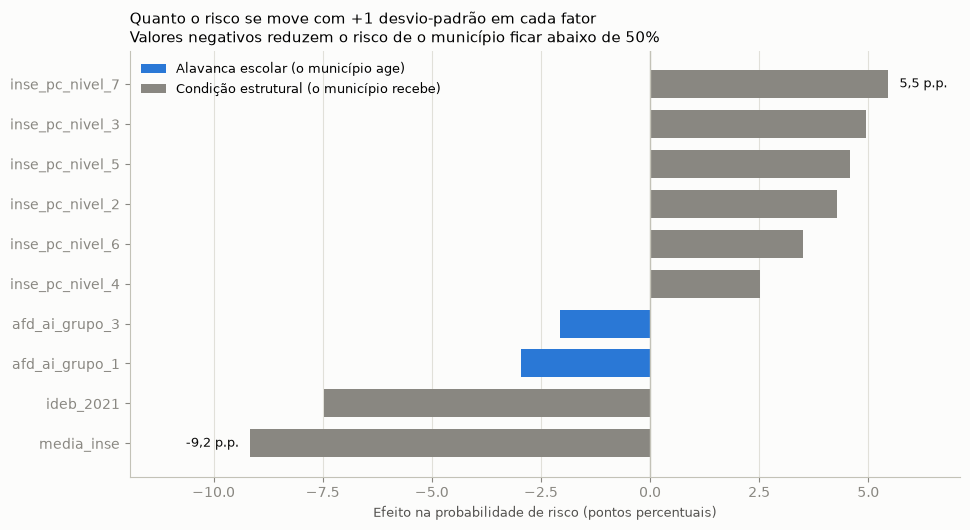

In [3]:
principais = efeitos.head(10).sort_values("efeito_pp_no_risco")
cores = [SERIE[0] if n == "alavanca escolar" else MUDO for n in principais["natureza"]]

fig, eixo = plt.subplots(figsize=(9.8, 5.4))
eixo.barh(principais.index, principais["efeito_pp_no_risco"], color=cores, height=0.7)
eixo.axvline(0, color=EIXO, linewidth=1)

for nome in (principais.index[0], principais.index[-1]):
    valor = principais.loc[nome, "efeito_pp_no_risco"]
    eixo.text(valor + (0.25 if valor > 0 else -0.25), nome, f"{num(valor, 1)} p.p.",
              va="center", ha="left" if valor > 0 else "right", fontsize=9.5, color=TINTA)

from matplotlib.patches import Patch
eixo.legend(handles=[Patch(facecolor=SERIE[0], label="Alavanca escolar (o município age)"),
                     Patch(facecolor=MUDO, label="Condição estrutural (o município recebe)")],
            loc="upper left", fontsize=9, framealpha=0.9)

# Folga nas duas pontas para os rótulos dos extremos não encostarem no eixo.
menor, maior = principais["efeito_pp_no_risco"].min(), principais["efeito_pp_no_risco"].max()
eixo.set_xlim(menor * 1.30, maior * 1.30)

eixo.set_title("Quanto o risco se move com +1 desvio-padrão em cada fator\n"
               "Valores negativos reduzem o risco de o município ficar abaixo de 50%", loc="left")
eixo.set_xlabel("Efeito na probabilidade de risco (pontos percentuais)")
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "04_efeitos_marginais", IMAGENS)
plt.show()

### A resposta, em três camadas

**1ª — a condição socioeconômica.** O INSE médio é o maior efeito contínuo do modelo, e as
proporções de alunos em cada nível do INSE ocupam metade do top 10. É a condição que o município
recebe, não a que ele escolhe.

**2ª — o desempenho pregresso.** Um desvio-padrão a mais no IDEB de 2021 vem logo atrás. É o
acúmulo de anos de trabalho da rede, e o mais difícil de mover no curto prazo.

**3ª — as alavancas escolares.** Formação docente e tamanho de turma são o que um gestor
municipal efetivamente controla — e valem, cada uma, cerca de **um terço** do que valem as duas
primeiras.

**E a camada que não aparece neste gráfico, porque não é uma variável contínua: a unidade
federativa.** Na *permutation importance* do notebook 03, embaralhar `sigla_uf` derruba o PR-AUC
em **0,345** — duas vezes e meia o efeito do INSE (0,137) e mais de três vezes o do IDEB (0,103).
É a variável mais importante do modelo inteiro.

Duas leituras opostas cabem no mesmo conjunto de números, e as duas são verdadeiras:

- **Desanimadora:** as alavancas municipais são pequenas diante da estrutura herdada.
- **Encorajadora:** a maior fonte de variação não é a renda das famílias — é a **política
  pública estadual**. Se o resultado fosse determinado pela condição socioeconômica, não haveria
  o que recomendar a um gestor.

---

## 2. Quais municípios apresentam maior risco educacional?

Esta pergunta agora tem resposta **direta**: o classificador emite, para cada município, a
probabilidade de ele estar em risco. Não há construção intermediária nem métrica derivada — é a
saída nativa do modelo, ordenável.

In [4]:
ranking = ranking_de_risco(modelo, X)
ranking.head(12).round(3)

,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,prob_risco
0,2924405,BA,Nordeste,22.51,0.990
1,2916609,BA,Nordeste,36.62,0.987
2,2902401,BA,Nordeste,33.61,0.986
3,2902302,BA,Nordeste,60.00,0.986
4,2900900,BA,Nordeste,23.91,0.984
5,2907202,BA,Nordeste,20.93,0.984
6,2915304,BA,Nordeste,25.00,0.983
7,2919009,BA,Nordeste,21.21,0.983
8,2908606,BA,Nordeste,28.14,0.980
9,2910008,BA,Nordeste,41.07,0.980


In [5]:
# O corte de prioridade é uma decisão de cobertura, não o 0,5 do software.
cobertura = limiar_por_recall(y, modelo.predict_proba(X)[:, 1], recall_desejado=0.80)
limiar = cobertura["limiar"]

ranking["prioridade"] = np.where(ranking["prob_risco"] >= limiar,
                                 "prioritário", "acompanhar")
resumo_prioridade = (ranking.groupby("prioridade")
                     .agg(municipios=("id_municipio", "size"),
                          taxa_media_observada=("taxa_alfabetizacao", "mean"),
                          risco_medio=("prob_risco", "mean"))
                     .round(3))
print(f"Limiar para cobrir 80% dos municípios em risco: {num(limiar, 3)}")
resumo_prioridade

Limiar para cobrir 80% dos municípios em risco: 0,286


,municipios,taxa_media_observada,risco_medio
prioridade,,,
acompanhar,3587,71.21,0.083
prioritário,1861,46.59,0.639


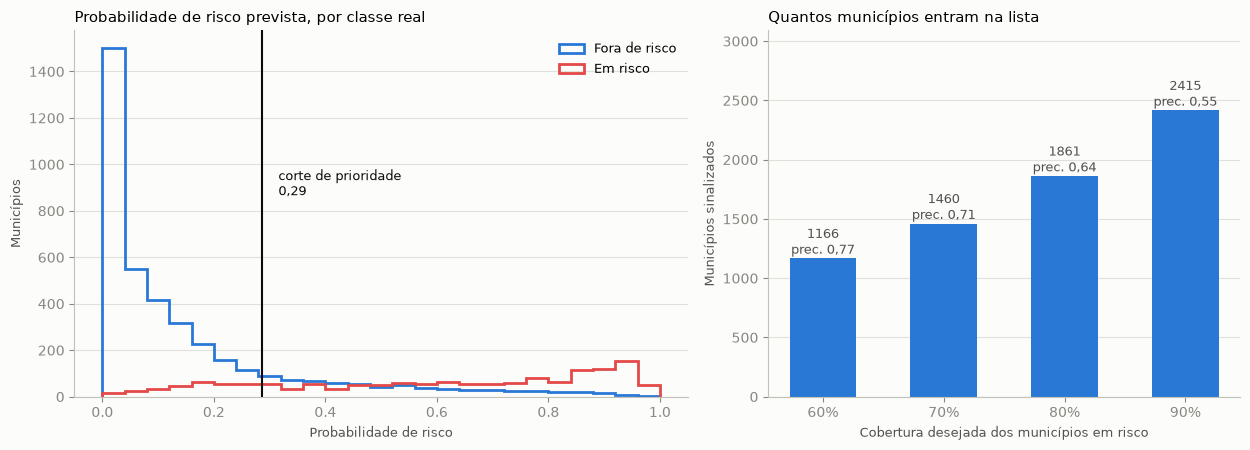

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(12.6, 4.6),
                          gridspec_kw={"width_ratios": [1.3, 1]})

# --- Painel A: o modelo separa as duas classes ---
for rotulo, cor, mascara in [("Fora de risco", SERIE[0], y == 0),
                             ("Em risco", NEGATIVO, y == 1)]:
    eixos[0].hist(modelo.predict_proba(X)[:, 1][mascara], bins=np.arange(0, 1.02, 0.04),
                  histtype="step", linewidth=2, color=cor, label=rotulo)
eixos[0].axvline(limiar, color=TINTA, linewidth=1.5)
eixos[0].text(limiar + 0.03, eixos[0].get_ylim()[1] * 0.55,
              f"corte de prioridade\n{num(limiar, 2)}", fontsize=9, color=TINTA)
eixos[0].set_title("Probabilidade de risco prevista, por classe real", loc="left")
eixos[0].set_xlabel("Probabilidade de risco")
eixos[0].set_ylabel("Municípios")
eixos[0].legend(loc="upper right", fontsize=9)
limpar(eixos[0])

# --- Painel B: quantos municípios entram conforme a cobertura desejada ---
coberturas = pd.DataFrame([limiar_por_recall(y, modelo.predict_proba(X)[:, 1], r)
                           for r in (0.6, 0.7, 0.8, 0.9)])
eixos[1].bar([f"{int(r*100)}%" for r in coberturas["recall_desejado"]],
             coberturas["municipios_sinalizados"], color=SERIE[0], width=0.55)
for i, (n, p) in enumerate(zip(coberturas["municipios_sinalizados"],
                               coberturas["precisao_risco"])):
    eixos[1].text(i, n + 40, f"{n}\nprec. {num(p, 2)}", ha="center",
                  fontsize=9.5, color=TINTA_2)
eixos[1].set_title("Quantos municípios entram na lista", loc="left")
eixos[1].set_xlabel("Cobertura desejada dos municípios em risco")
eixos[1].set_ylabel("Municípios sinalizados")
eixos[1].set_ylim(0, coberturas["municipios_sinalizados"].max() * 1.28)
limpar(eixos[1])

fig.tight_layout()
salvar(fig, "04_ranking_risco", IMAGENS)
plt.show()

In [7]:
# O ranking completo vira artefato entregável.
destino = RELATORIOS / "ranking_risco_municipios.csv"
ranking.to_csv(destino, index=False, encoding="utf-8")
print(f"{len(ranking)} municípios gravados em reports/{destino.name}")
ranking.head(5)

5448 municípios gravados em reports/ranking_risco_municipios.csv


,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,prob_risco,prioridade
0,2924405,BA,Nordeste,22.51,0.990191,prioritário
1,2916609,BA,Nordeste,36.62,0.986808,prioritário
2,2902401,BA,Nordeste,33.61,0.986403,prioritário
3,2902302,BA,Nordeste,60.00,0.986285,prioritário
4,2900900,BA,Nordeste,23.91,0.984397,prioritário


**Como usar, e como não usar.**

O painel da esquerda mostra que o modelo separa bem as duas classes, mas **há sobreposição** — e
é ela que torna o corte uma decisão de política. O painel da direita põe preço nessa decisão:
cobrir 80% dos municípios em risco significa sinalizar mais municípios e aceitar precisão menor,
ou seja, mais visitas técnicas a quem não precisava.

**A lista não é um veredito sobre gestão.** Ela ordena municípios pelo risco que as condições
observadas produzem — contexto socioeconômico, corpo docente, estrutura de turmas, desempenho
pregresso. Um município no topo pode ter uma gestão excelente enfrentando condições muito
adversas. A lista diz **onde olhar primeiro**, não quem está errando.

---

## 3. Quais regiões possuem padrões semelhantes?

A pergunta pede agrupar territórios por semelhança. A resposta sai do próprio classificador, em
duas leituras que precisam coincidir para que duas regiões sejam de fato "parecidas":

1. **o nível de risco previsto** — quão frequente é o risco naquela região;
2. **os motores do risco** — quais fatores mais empurram o risco para cima ali, medidos pela
   contribuição média (SHAP) de cada variável dentro da região.

As dummies de UF ficam fora dessa leitura: elas *identificam* o território em vez de explicá-lo,
e usá-las tornaria a resposta circular.

In [8]:
import shap

matriz = modelo.named_steps["preprocessamento"].transform(X)
nomes = nomes_das_features(modelo)
valores_shap = pd.DataFrame(
    shap.LinearExplainer(modelo.named_steps["modelo"], matriz).shap_values(matriz),
    columns=nomes)

perfil = perfil_por_regiao(modelo, X, valores_shap, n_fatores=3)
perfil

Background dataset has 5448 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5448 when initializing the masker.


,regiao,municipios,risco_medio_previsto,motores_do_risco
0,Norte,435,0.528,ideb_2021 · media_inse · inse_pc_nivel_2
1,Nordeste,1780,0.458,media_inse · ideb_2021 · inse_pc_nivel_3
2,Sul,1143,0.220,inse_pc_nivel_7 · inse_pc_nivel_6 · inse_pc_ni...
3,Sudeste,1626,0.094,inse_pc_nivel_5 · inse_pc_nivel_6 · inse_pc_ni...
4,Centro-Oeste,464,0.079,inse_pc_nivel_5 · inse_pc_nivel_4 · ideb_2021


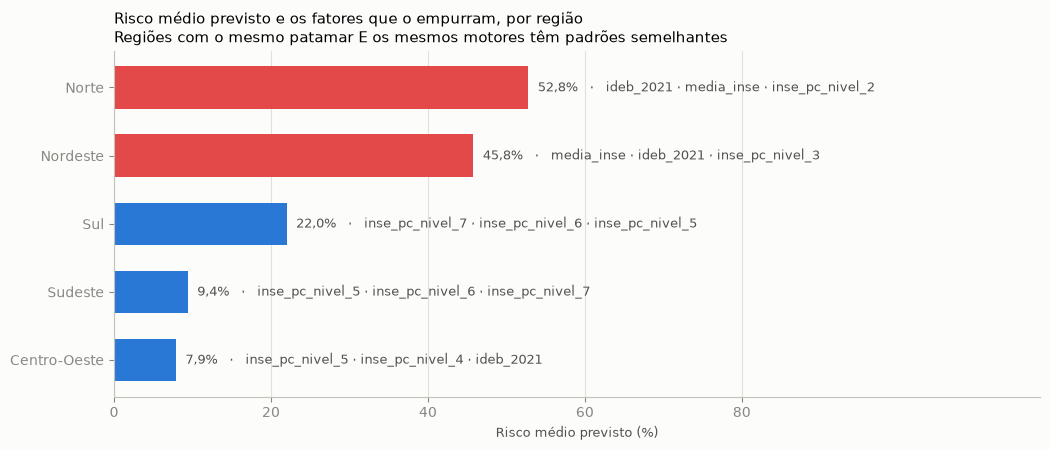

In [9]:
fig, eixo = plt.subplots(figsize=(10.6, 4.6))
ordenado = perfil.sort_values("risco_medio_previsto")

eixo.barh(ordenado["regiao"], ordenado["risco_medio_previsto"] * 100,
          color=[NEGATIVO if v > 0.4 else SERIE[0] for v in ordenado["risco_medio_previsto"]],
          height=0.62)

for _, linha in ordenado.iterrows():
    eixo.text(linha["risco_medio_previsto"] * 100 + 1.2, linha["regiao"],
              f"{num(linha['risco_medio_previsto'] * 100, 1)}%   ·   {linha['motores_do_risco']}",
              va="center", fontsize=9.5, color=TINTA_2)

eixo.set_title("Risco médio previsto e os fatores que o empurram, por região\n"
               "Regiões com o mesmo patamar E os mesmos motores têm padrões semelhantes",
               loc="left")
eixo.set_xlabel("Risco médio previsto (%)")
eixo.set_xlim(0, 118)
eixo.set_xticks([0, 20, 40, 60, 80])
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "04_padroes_regionais", IMAGENS)
plt.show()

### A resposta — e ela contraria a formulação da pergunta

Os cinco territórios se organizam em **três padrões**, não cinco:

- **Norte e Nordeste formam um par.** Patamar de risco alto e os **mesmos motores**: desempenho
  pregresso baixo e nível socioeconômico. São regiões diferentes no mapa e o mesmo problema no
  modelo.
- **Sudeste, Centro-Oeste e Sul compartilham os motores** — nos três o risco é empurrado pela
  composição socioeconômica, não pelo desempenho pregresso. Mas **o Sul fica num patamar à
  parte**: 22,0% de risco médio contra 9,4% e 7,9%. Mesmo mecanismo, intensidade diferente.

Dito de outro modo: **dois mecanismos de risco e três patamares.** Onde o IDEB pregresso aparece
entre os motores (Norte e Nordeste), o risco é alto; onde só a composição do INSE aparece, o
risco é baixo — e a distância do Sul para o Sudeste é de grau, não de natureza.

Mas a leitura mais útil é a que aparece quando se desce do agregado: **os padrões não respeitam
as fronteiras regionais.** Há municípios de perfil "Norte/Nordeste" no interior do Sudeste, e
municípios de perfil "Sudeste" dentro do Nordeste — o Ceará é o exemplo mais claro.

**Consequência para a política pública:** um programa desenhado por região erraria o alvo. A
focalização eficiente é **por perfil de risco**, e o ranking da §2 já entrega essa lista pronta,
município a município, sem precisar de fronteira nenhuma.

---

## 4. Como prever municípios que podem não atingir as metas futuras?

O Compromisso Nacional Criança Alfabetizada pactuou metas por município. Elas chegam aqui
**apenas como régua de comparação** — nunca entraram no modelo, porque são calculadas a partir
da taxa de 2023 de cada município e seriam vazamento como preditor.

Cruzando a meta com o risco previsto, os municípios se separam em três situações com
diagnósticos diferentes.

In [10]:
gold = ler_particionado(LAKE_DIR / "gold" / "alfabetizacao_por_municipio")
metas = gold[gold["ano"] == 2024][["id_municipio", "meta_2025"]]

situacao = situacao_frente_a_meta(ranking, metas, limiar_risco=limiar)
quadro = (situacao.groupby("situacao")
          .agg(municipios=("id_municipio", "size"),
               taxa_media=("taxa_alfabetizacao", "mean"),
               risco_medio_previsto=("prob_risco", "mean"))
          .round(3))
quadro["% do total"] = (quadro["municipios"] / len(situacao) * 100).round(1)
quadro

,municipios,taxa_media,risco_medio_previsto,% do total
situacao,,,,
1. Meta já atingida,2322,77.682,0.139,43.4
"2. Abaixo da meta, sem sinal de risco estrutural",1575,60.520,0.108,29.4
3. Abaixo da meta e sinalizado em risco,1455,42.407,0.654,27.2


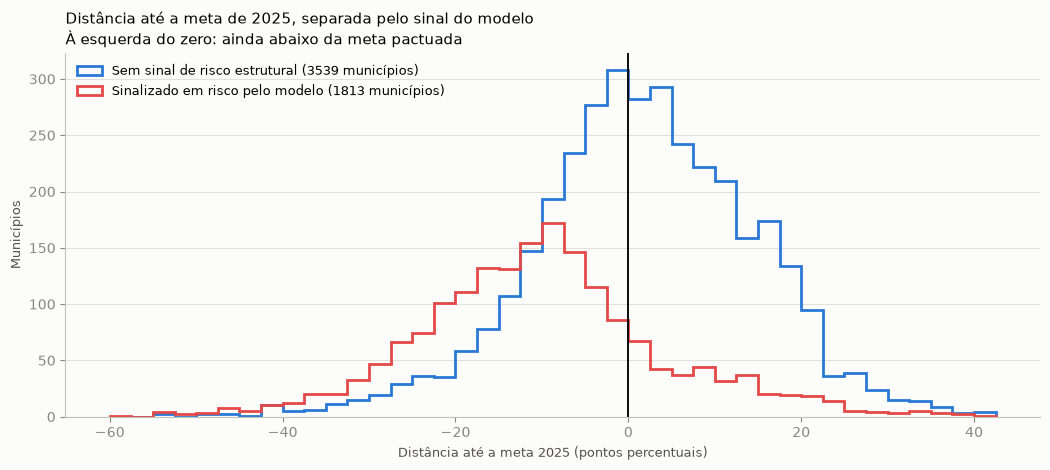

In [11]:
fig, eixo = plt.subplots(figsize=(10.6, 4.8))

faixas = np.arange(-60, 45, 2.5)
for cor, (rotulo, dados) in zip(
    [SERIE[0], NEGATIVO],
    [("Sem sinal de risco estrutural",
      situacao.loc[~situacao["sinalizado_em_risco"], "taxa_alfabetizacao"]
      - situacao.loc[~situacao["sinalizado_em_risco"], "meta_2025"]),
     ("Sinalizado em risco pelo modelo",
      situacao.loc[situacao["sinalizado_em_risco"], "taxa_alfabetizacao"]
      - situacao.loc[situacao["sinalizado_em_risco"], "meta_2025"])],
):
    eixo.hist(dados, bins=faixas, histtype="step", linewidth=2, color=cor,
              label=f"{rotulo} ({len(dados)} municípios)")

eixo.axvline(0, color=TINTA, linewidth=1.4)
eixo.set_title("Distância até a meta de 2025, separada pelo sinal do modelo\n"
               "À esquerda do zero: ainda abaixo da meta pactuada", loc="left")
eixo.set_xlabel("Distância até a meta 2025 (pontos percentuais)")
eixo.set_ylabel("Municípios")
eixo.legend(loc="upper left", fontsize=9)
limpar(eixo)
fig.tight_layout()
salvar(fig, "04_metas", IMAGENS)
plt.show()

**O que a separação entrega.** "Municípios abaixo da meta" é um número que não orienta ação.
Separá-los pelo sinal do modelo transforma o número em decisão de alocação:

- **Abaixo da meta, sem sinal de risco estrutural** — as condições do município comportam a
  meta. O que falta é execução, e a resposta é **apoio técnico**, com retorno rápido.
- **Abaixo da meta e sinalizado em risco** — as condições observadas não sustentam a meta.
  Cobrar resultado sem mudar as condições é cobrar o impossível; a resposta é **investimento
  estruturante**, com retorno em anos.

A ressalva metodológica precisa acompanhar qualquer número desta seção: como a meta de cada
município deriva do seu próprio resultado de 2023, "não atingir a meta" significa "não manter a
trajetória pactuada a partir do próprio ponto de partida" — não "estar abaixo de um padrão
nacional".

---

## 5. O que estas análises não autorizam a afirmar

1. **Não são causais.** Todos os efeitos são associações condicionais. Nenhuma intervenção pode
   ser justificada apenas por estes coeficientes.
2. **Não avaliam gestão.** O ranking ordena municípios pelo risco que as condições observadas
   produzem. Um município no topo pode ter gestão excelente em condições muito adversas.
3. **Não descrevem alunos.** A premissa é que o contexto do município determina a chance da
   criança — duas crianças do mesmo município recebem a mesma predição.
4. **Não explicam o efeito da UF.** O modelo mede o tamanho; a explicação está fora da base,
   que não tem nenhuma variável de política educacional.
5. **Não cobrem o país inteiro.** 25 das 27 UFs: o Distrito Federal não tem rede municipal e
   Roraima está ausente do arquivo do INEP.
6. **Não projetam ciclos futuros.** O modelo descreve a estrutura de 2024. Projetar 2025 exigiria
   as características de 2025, que ainda não existem.

---

## Conclusão — as cinco perguntas

**1 e 5. Quais fatores mais impactam / têm maior influência?**
Em ordem medida pela *permutation importance*: a **unidade federativa** (queda de 0,345 no
PR-AUC), a **condição socioeconômica** (0,137), o **desempenho pregresso** do município (0,103)
e, por último, as **alavancas escolares** sob gestão municipal — formação docente e tamanho de
turma, uma ordem de grandeza abaixo.

**2. Quais municípios apresentam maior risco?**
O classificador entrega a lista pronta, ordenada por probabilidade de risco, em
`reports/ranking_risco_municipios.csv`. O corte é uma decisão de cobertura, não o padrão do
software: cobrir 80% dos municípios em risco tem um preço em precisão, e o modelo mostra qual.

**3. Quais regiões possuem padrões semelhantes?**
Três padrões, não cinco: Norte e Nordeste compartilham patamar e motores; Sudeste e
Centro-Oeste formam outro par; o Sul fica isolado. Mas os padrões **atravessam as fronteiras** —
a focalização eficiente é por perfil de risco, não por território.

**4. Como prever quem não atingirá as metas?**
Cruzando o risco previsto com a meta pactuada, separando quem precisa de **apoio à execução** de
quem precisa de **investimento estruturante**.